In [6]:
# Import Library
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# Load model
model = models.segmentation.deeplabv3_resnet101(pretrained=True).eval()

In [8]:
# Load and preprocess image
img = Image.open('assets/image3.jpg').convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(img).unsqueeze(0)  # Add batch dim

In [9]:
# Inference
with torch.no_grad():
    output = model(input_tensor)['out'][0]
seg = output.argmax(0).byte().cpu().numpy()

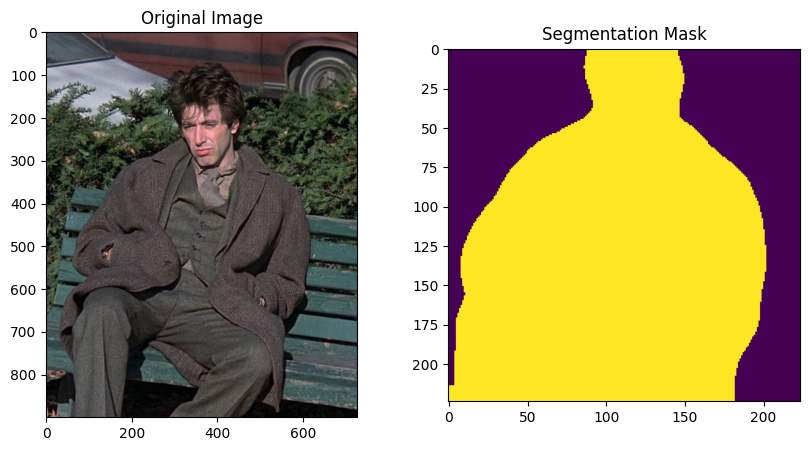

In [10]:
# Show original and mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(seg)
plt.title("Segmentation Mask")
plt.show()